# 10 — Interpretability

This notebook evaluates the final model, computes interpretability metrics in R, and uses Python (via reticulate) only for SHAP calculations and SHAP plots.

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(reticulate)
  library(tidyverse)
  library(readr)
  library(knitr)
  library(caret)
})

In [2]:
# Load R scripts
source("../src/interpretability.R")
source("../src/visualization.R")

In [3]:
# Load data
X_te <- read_csv("../data/processed/X_te_prep.csv", show_col_types = FALSE)
y_te <- read_csv("../data/processed/y_te.csv", show_col_types = FALSE)$target
ids <- read_csv("../data/processed/test_ids.csv", show_col_types = FALSE)$id
data_list <- readRDS("../data/processed/final_migraine_with_prob.rds")

In [4]:
# Preparate model
num_cols <- names(X_te)[sapply(X_te, is.numeric)]
cat_cols <- names(X_te)[sapply(X_te, function(x) is.factor(x) || is.character(x))]
drop_cols <- unlist(lapply(cat_cols, function(col) {
  levels <- unique(X_te[[col]])
  if(length(levels) > 1) {
    paste0(col, "_", levels[1])
  } else {
    NULL
  }
}))

X_te2 <- X_te[, !colnames(X_te) %in% drop_cols]

log_model <- glm(y_te ~ ., family = binomial, data = X_te2)

pred_fun <- function(model, newdata) {
  suppressWarnings(predict(model, newdata = newdata, type = "response"))
}

In [5]:
# Permutation importance
ids <- seq_len(nrow(X_te2))

imp_df <- compute_permutation_importance(
  X = X_te2,
  y = y_te,
  ids = ids,
  model = log_model,
  pred_fun = pred_fun
)

kable(imp_df)
write.csv(imp_df, "../reports/tables/permutation_importance.csv", row.names = FALSE)



|Variable                    | Importance|
|:---------------------------|----------:|
|num__prev_attacks           | -0.0657728|
|num__visit_number           | -0.0335651|
|num__days_since_first_visit | -0.0137809|
|num__airq                   |  0.0018077|
|num__airq_prev_mean         | -0.0012892|
|cat__hatype_Aura            | -0.0103331|
|cat__hatype_Mixed           | -0.0014157|
|cat__hatype_No Aura         |  0.0000000|
|cat__medication_continuing  | -0.0074056|
|cat__medication_none        | -0.0454411|
|cat__medication_reduced     |  0.0000000|
|cat__sex_female             | -0.0000888|
|cat__sex_male               |  0.0000000|
|cat__study_season_autumn    | -0.0085295|
|cat__study_season_spring    |  0.0000941|
|cat__study_season_summer    | -0.0013463|
|cat__study_season_winter    |  0.0000000|
|cat__phase_No treatment     |  0.0011657|
|cat__phase_Under treatment  |  0.0000000|
|cat__age_band_18-30         | -0.0005282|
|cat__age_band_31-40         | -0.0057824|
|cat__age

Saving 6.67 x 6.67 in image


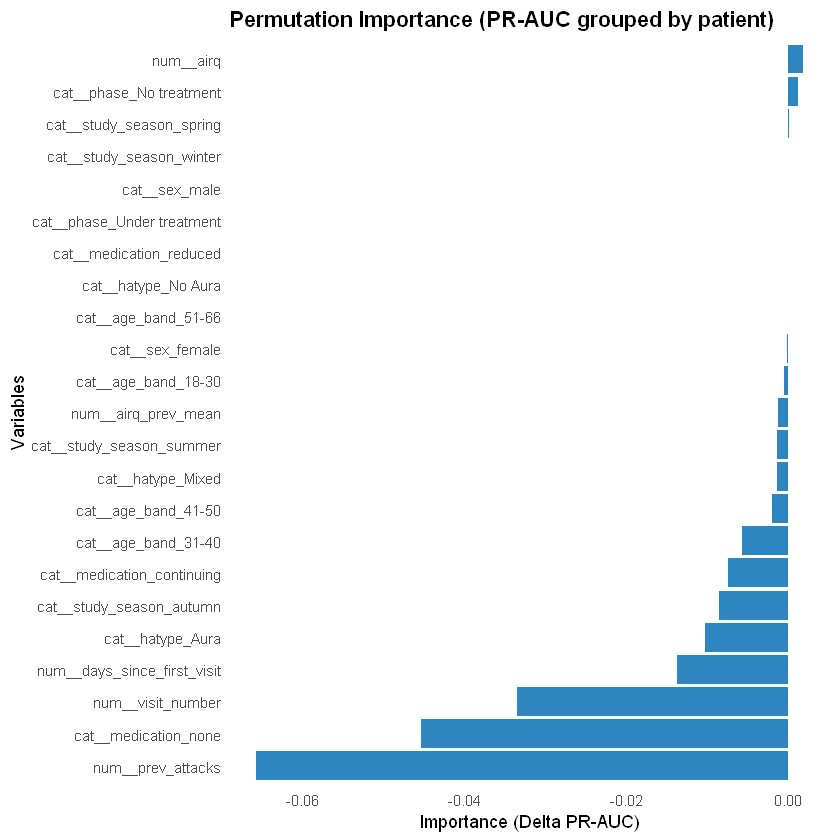

In [6]:
# Visualization
p_imp <- plot_permutation_importance(imp_df)
ggsave("../reports/figures/perm_importance.png", p_imp, dpi = 300)
p_imp

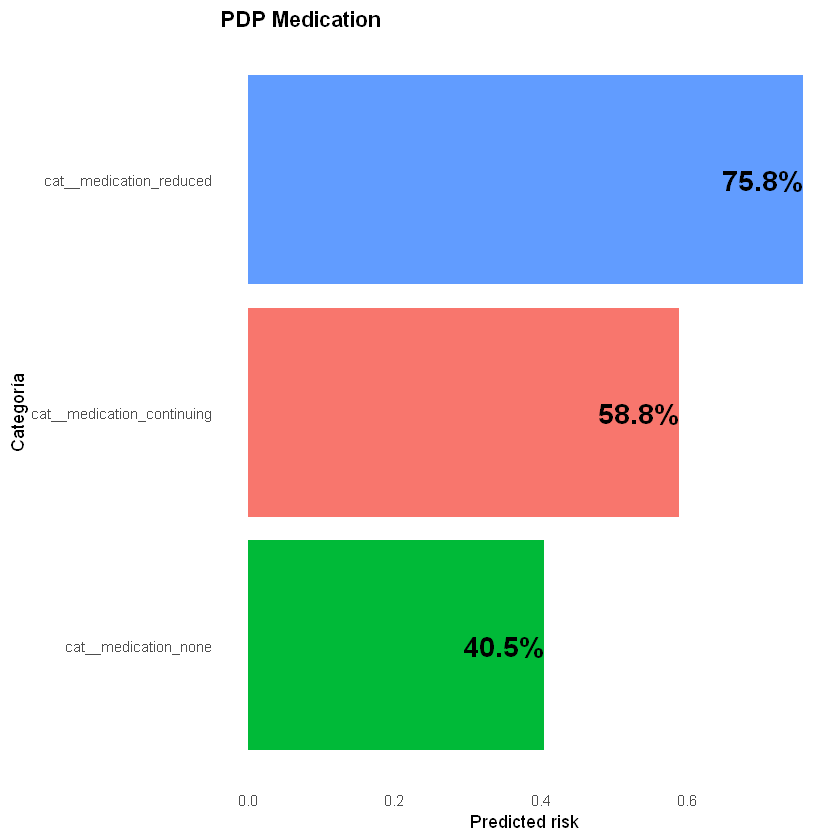

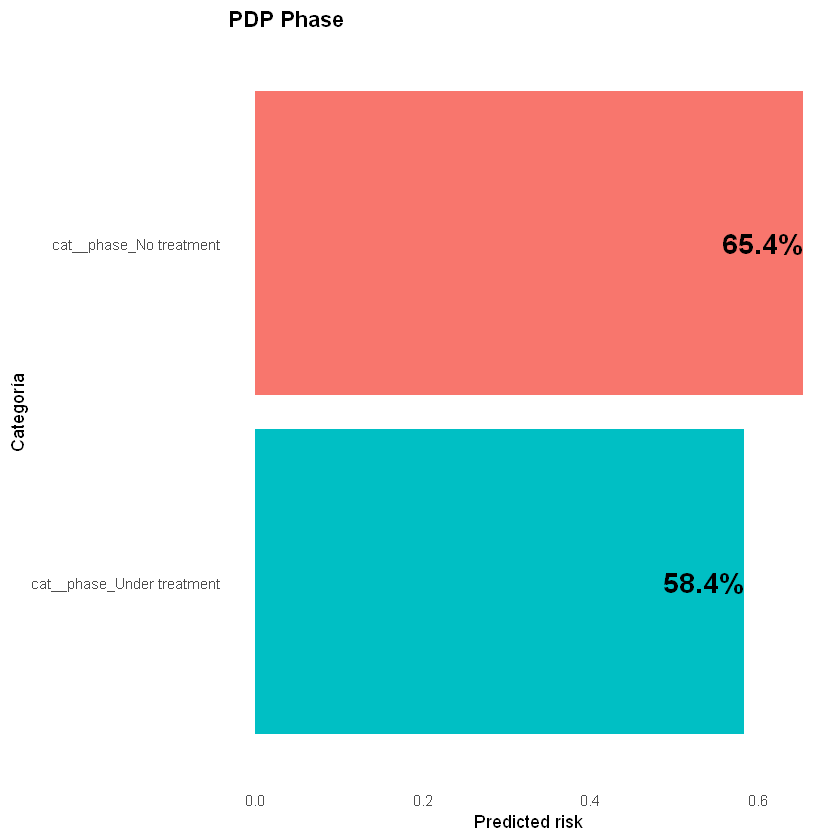

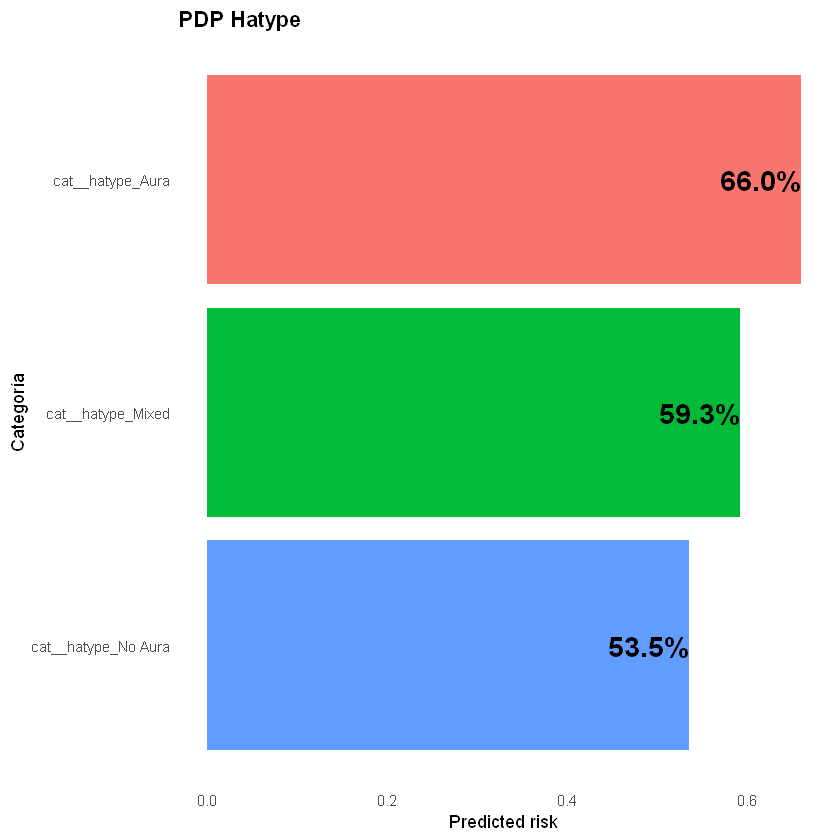

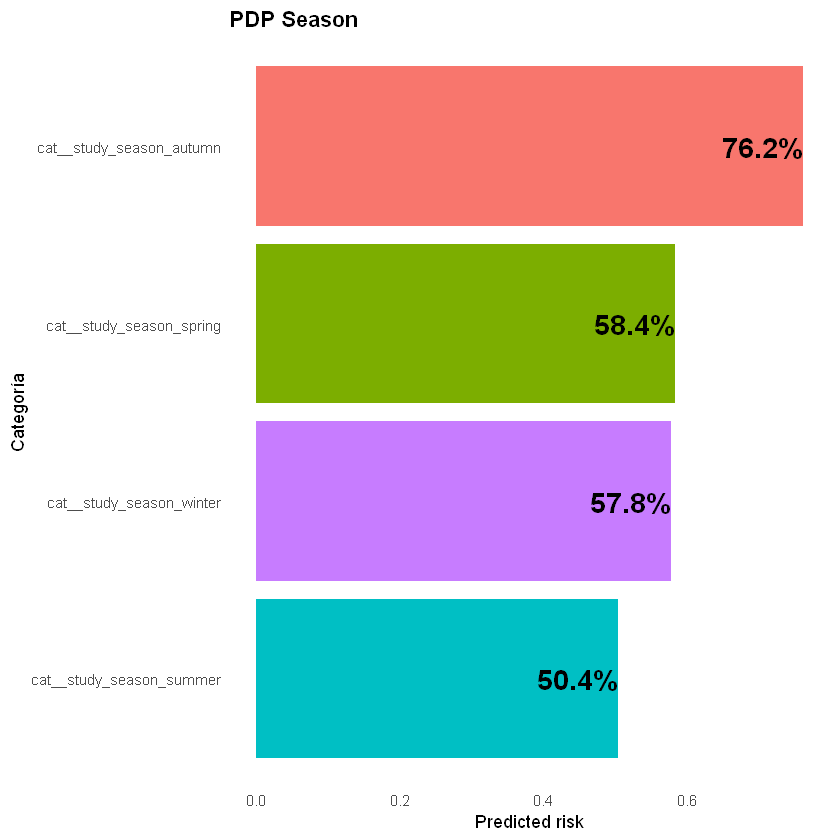

In [7]:
# PDP
results <- run_all_pdp(log_model, X_te, pred_fun)
plots <- build_all_pdp_plots(results)

for (i in seq_along(plots)) {
  
  print(plots[[i]])
  
  ggsave(
    paste0("../reports/figures/", results[[i]]$filename),
    plots[[i]],
    dpi = 300,
    width = 8,
    height = 6
  )
}

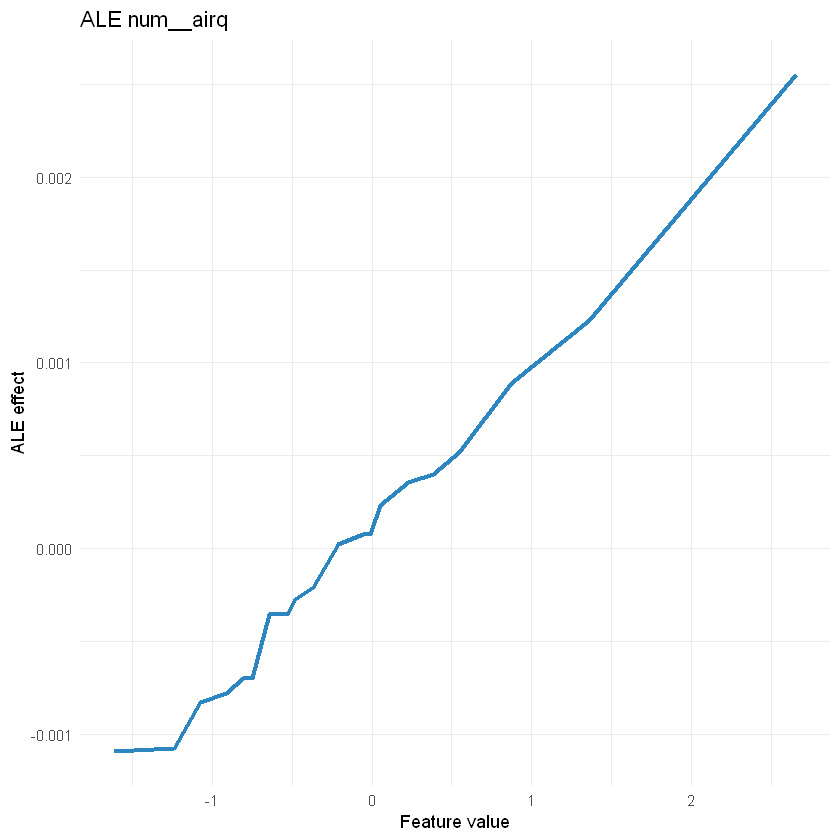

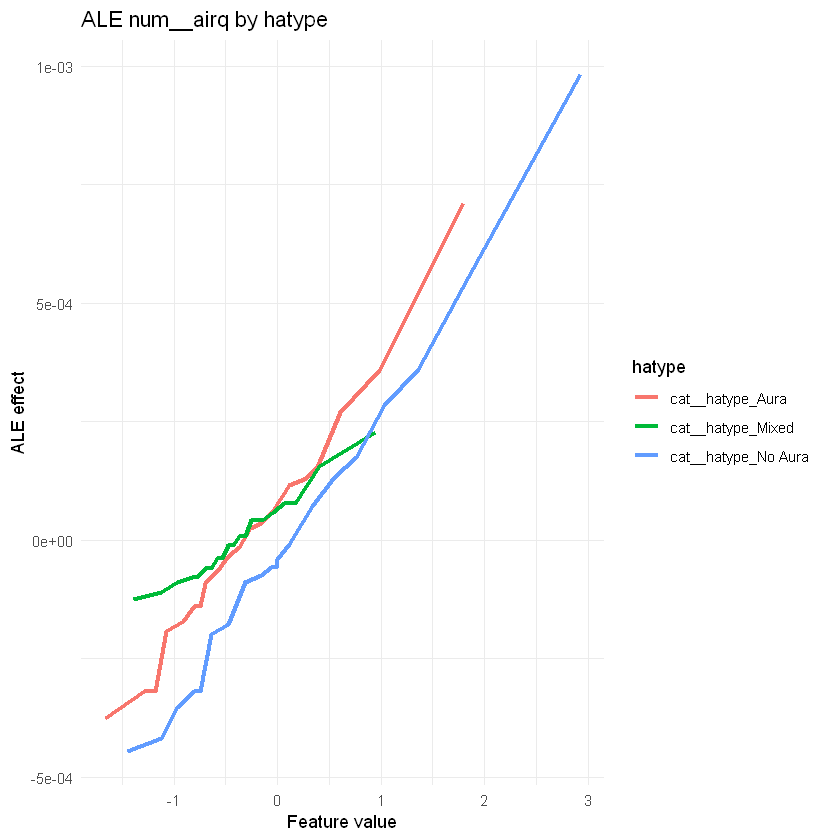

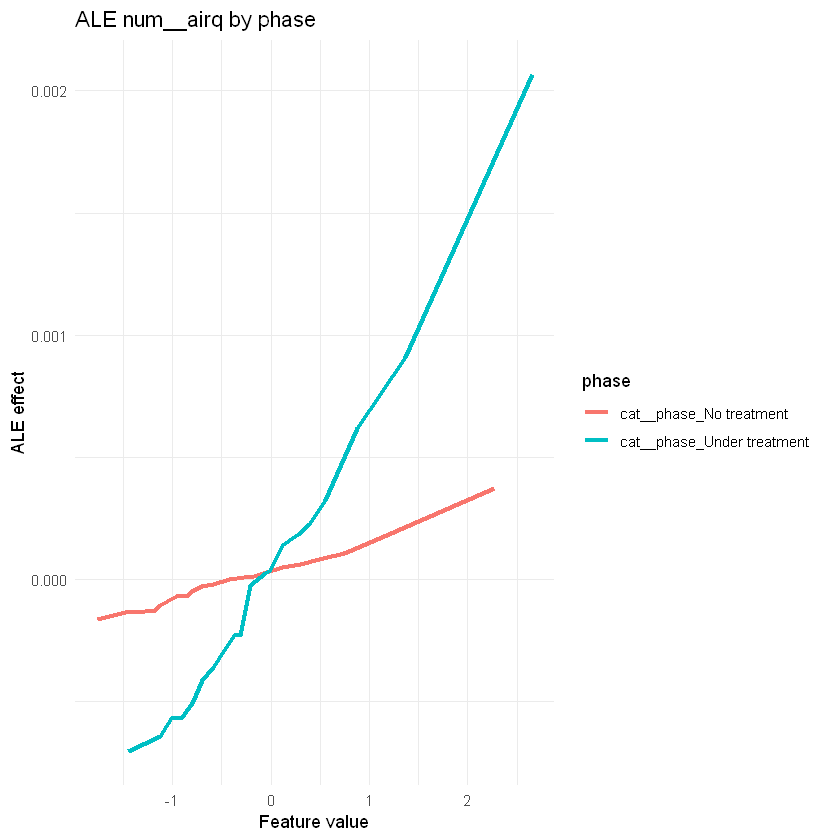

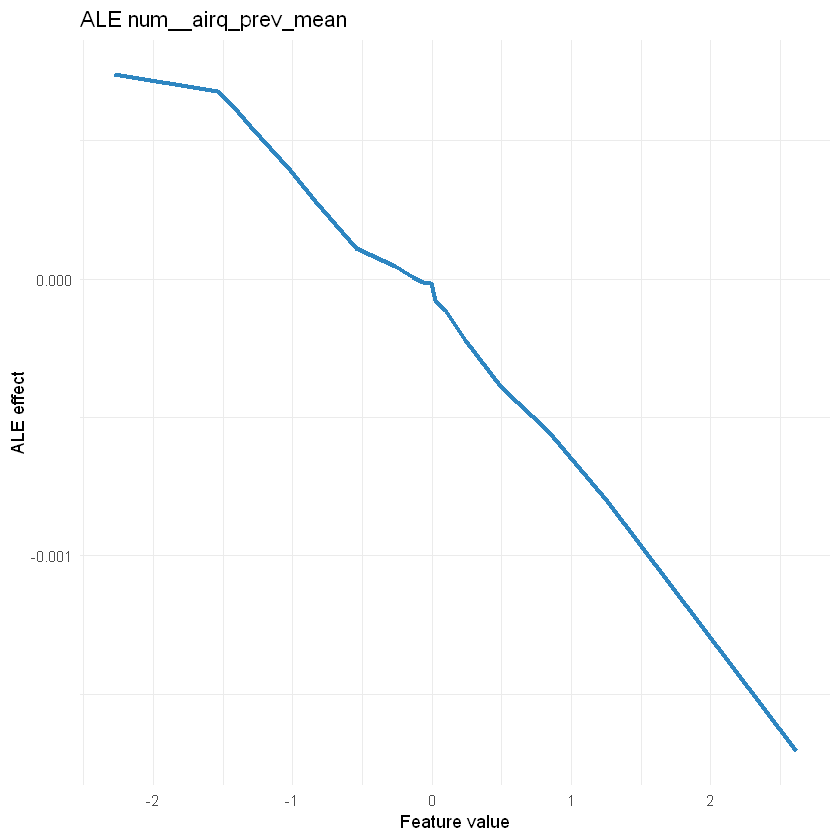

In [8]:
# ALE
ale_results <- run_all_ale(log_model, X_te, pred_fun)
ale_plots   <- build_all_ale_plots(ale_results)

targets <- c(
  "ALE num__airq",
  "ALE num__airq_prev_mean",
  "ALE num__airq by hatype",
  "ALE num__airq by phase"
)

for (i in seq_along(ale_results)) {
  plot_name <- trimws(ale_results[[i]]$name)
  if (plot_name %in% targets) print(ale_plots[[i]])
}

for (i in seq_along(ale_plots)) 
  ggsave(paste0("../reports/figures/", ale_results[[i]]$filename),
         ale_plots[[i]], dpi = 300, width = 8, height = 6)

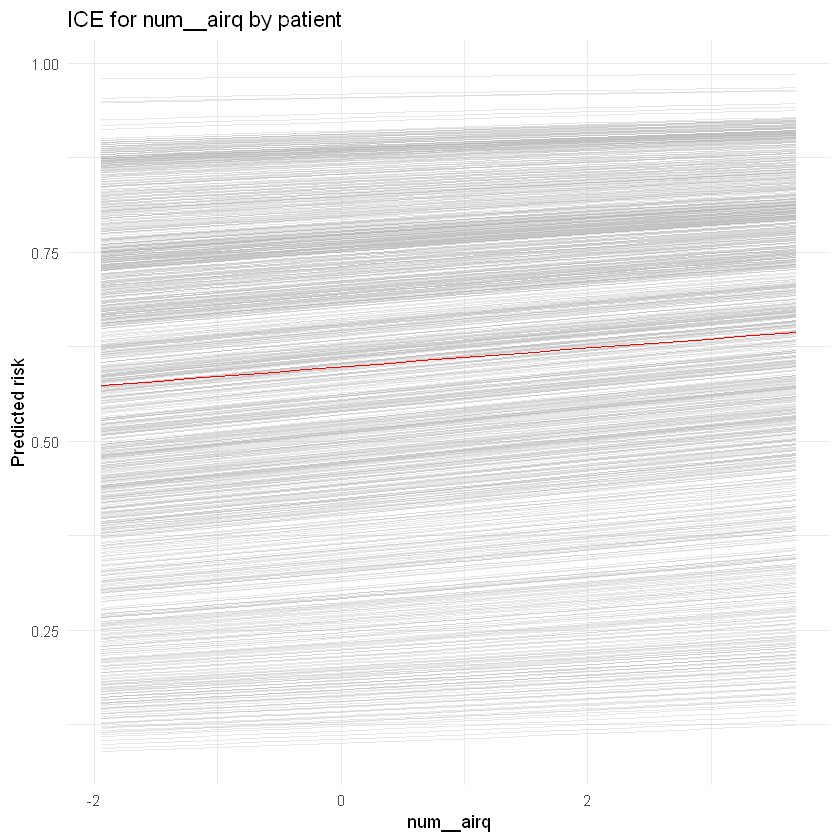

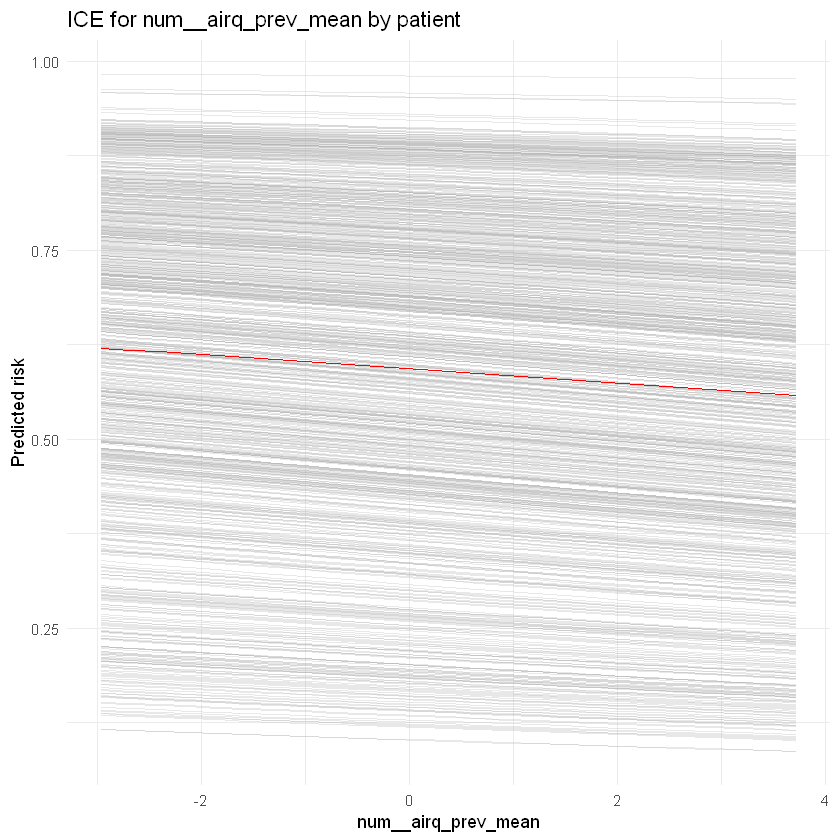

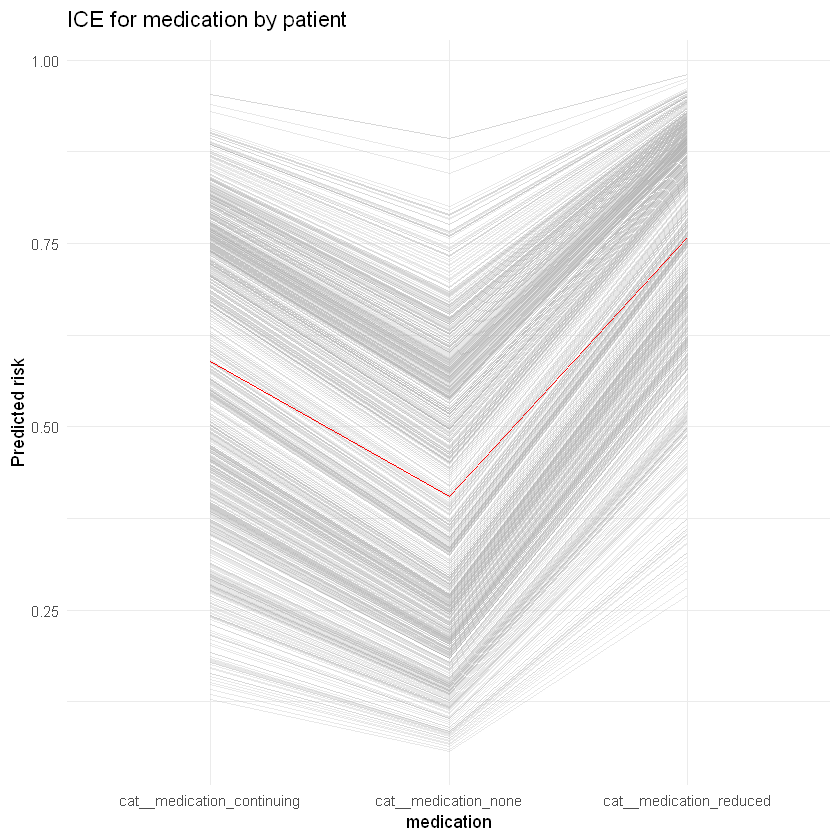

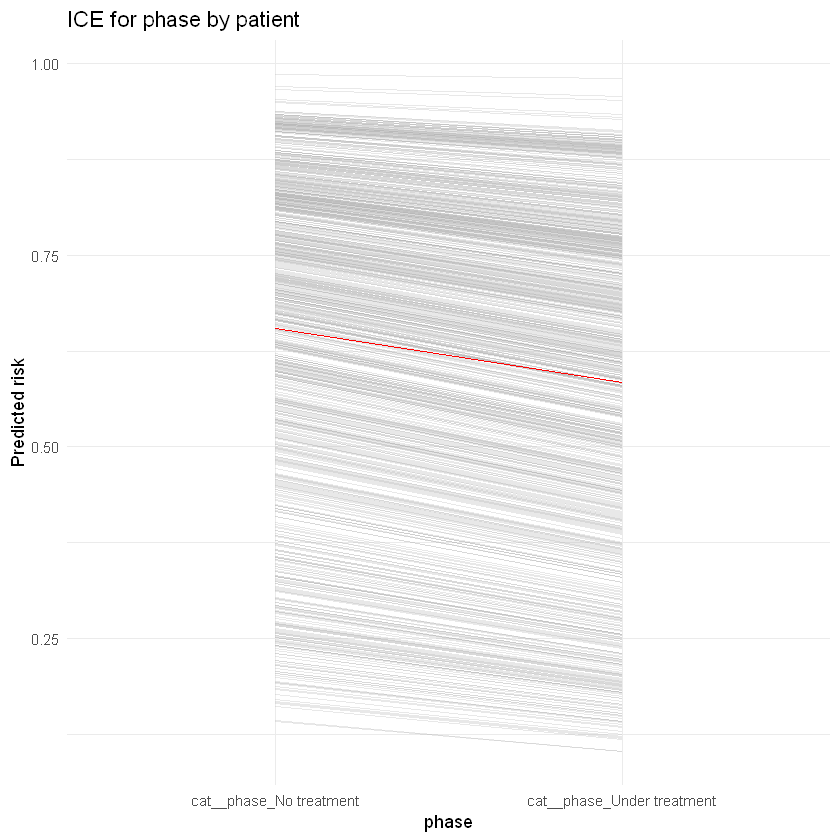

In [9]:
# ICE by patient
ids <- seq_len(nrow(X_te))

features <- list(
  list(name = "num__airq",           type = "numeric"),
  list(name = "num__airq_prev_mean", type = "numeric"),
  list(name = "medication",          type = "categorical", pattern = "^cat__medication_"),
  list(name = "phase",               type = "categorical", pattern = "^cat__phase_")
)

for (f in features) {

  if (f$type == "numeric") {
    ice <- compute_ice_by_id(X_te, ids, f$name, log_model, pred_fun)
  } else {
    lv <- grep(f$pattern, names(X_te), value = TRUE)
    ice <- compute_ice_by_id(X_te, ids, lv, log_model, pred_fun)
  }

  p <- plot_ice(ice, f$name)
  print(p)
  ggsave(filename = paste0("../reports/figures/ICE_", f$name, ".png"), plot = p, dpi = 300, width = 8, height = 6)}

In [10]:
# Sensitivity
# Identify features
med_cols   <- grep("^cat__medication_", colnames(X_te2), value = TRUE)
phase_cols <- grep("^cat__phase_",      colnames(X_te2), value = TRUE)
airq_col   <- "num__airq"
airq_prev_col <- "num__airq_prev_mean"

# Compute sensitivities
sens_med      <- compute_sensitivity(X_te2, ids, med_cols,      log_model, pred_fun)
sens_phase    <- compute_sensitivity(X_te2, ids, phase_cols,    log_model, pred_fun)
sens_airq     <- compute_sensitivity(X_te2, ids, airq_col,      log_model, pred_fun)
sens_airq_pm  <- compute_sensitivity(X_te2, ids, airq_prev_col, log_model, pred_fun)

# Real prev_attacks real
prev_real <- data_list %>%
  group_by(id) %>%
  summarise(prev_attacks_real = max(prev_attacks, na.rm = TRUE), .groups = "drop")

# Build sensitivity table
df_sens <- tibble(id = unique(ids)) %>%
  left_join(sens_med     %>% rename(sens_medication        = sensitivity), by = "id") %>%
  left_join(sens_phase   %>% rename(sens_fase              = sensitivity), by = "id") %>%
  left_join(sens_airq    %>% rename(sens_airq              = sensitivity), by = "id") %>%
  left_join(sens_airq_pm %>% rename(sens_airq_prev_mean    = sensitivity), by = "id") %>%
  left_join(prev_real,                                                     by = "id") %>%
  arrange(id)

head(round(df_sens, 3), 10)
readr::write_csv(df_sens, "../reports/tables/sensitivity_table.csv")

# Correlations
df_corr <- cor(
  df_sens %>% select(sens_medication, sens_fase, sens_airq, sens_airq_prev_mean),
  use = "complete.obs"
)
round(df_corr, 3)
readr::write_csv(as.data.frame(df_corr), "../reports/tables/sensitivity_correlations.csv")

id,sens_medication,sens_fase,sens_airq,sens_airq_prev_mean,prev_attacks_real
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.292,0.067,0.054,0.053,18
2,0.270,0.062,0.049,0.053,42
3,0.262,0.060,0.048,0.051,43
4,0.256,0.059,0.047,0.050,29
5,0.248,0.057,0.047,0.048,53
6,0.245,0.056,0.046,0.047,53
7,0.245,0.056,0.046,0.047,26
8,0.193,0.033,0.036,0.036,26
9,0.191,0.033,0.035,0.036,18


,sens_medication,sens_fase,sens_airq,sens_airq_prev_mean
sens_medication,1.000,0.598,0.632,0.605
sens_fase,0.598,1.000,0.972,0.963
sens_airq,0.632,0.972,1.000,0.985
sens_airq_prev_mean,0.605,0.963,0.985,1.000


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


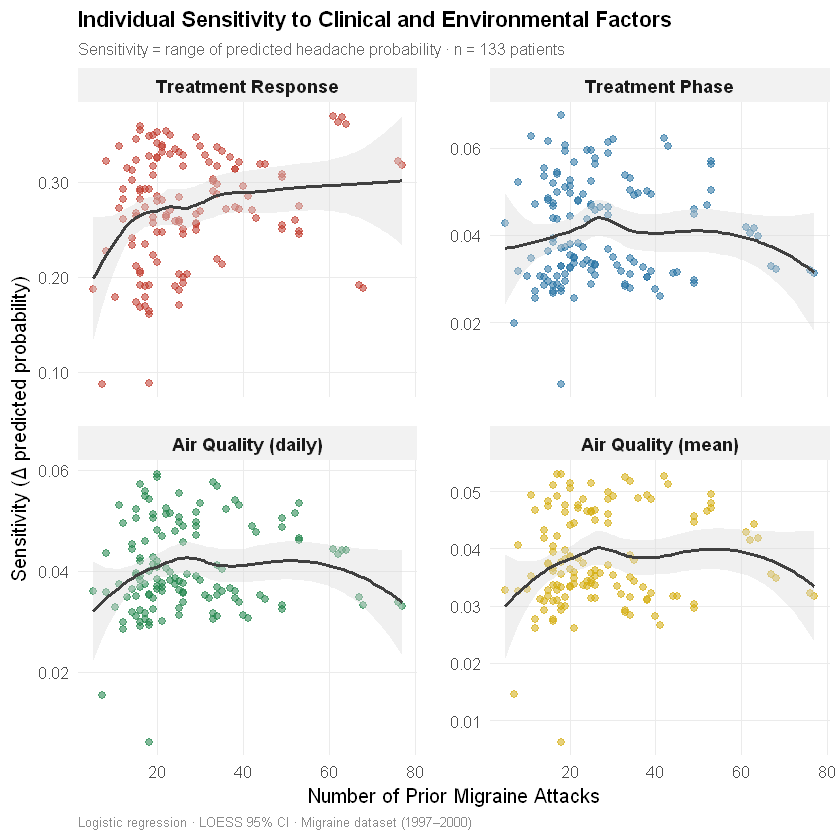

`geom_smooth()` using formula = 'y ~ x'


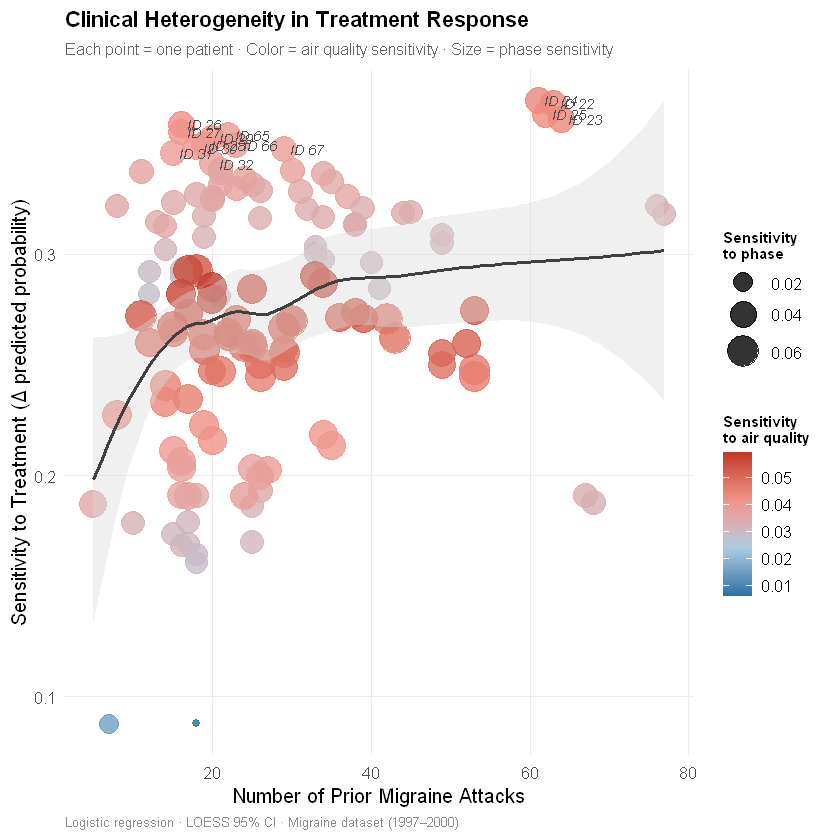

In [14]:
# Visualization
df_sens_plot <- df_sens %>% dplyr::filter(!is.na(prev_attacks_real))

p1 <- plot_sensitivity_facets(df_sens_plot)
p1
ggsave("../reports/figures/sensitivity_facets.png", p1, width = 10, height = 7, dpi = 300)
p2 <- plot_sensitivity_bubble(df_sens_plot)
p2
ggsave("../reports/figures/sensitivity_bubble.png", p2, width = 10, height = 7, dpi = 300)

In [15]:
# Setup Python
use_condaenv("bioai", required = TRUE)
src_path <- normalizePath("../src", winslash = "/")

py_run_string(paste0("
import sys
sys.path.insert(0, '", src_path, "')
import evaluation as eval_py
import visualization as viz_py
"))

eval_py <- py$eval_py
viz_py  <- py$viz_py

In [17]:
# Compute SHAP values
result      <- eval_py$compute_shap(
  "../models/logistic_regression_tuned.pkl",
  "../data/processed/X_te_prep.csv"
)
shap_values <- result[[1]]
X_shap      <- result[[2]]

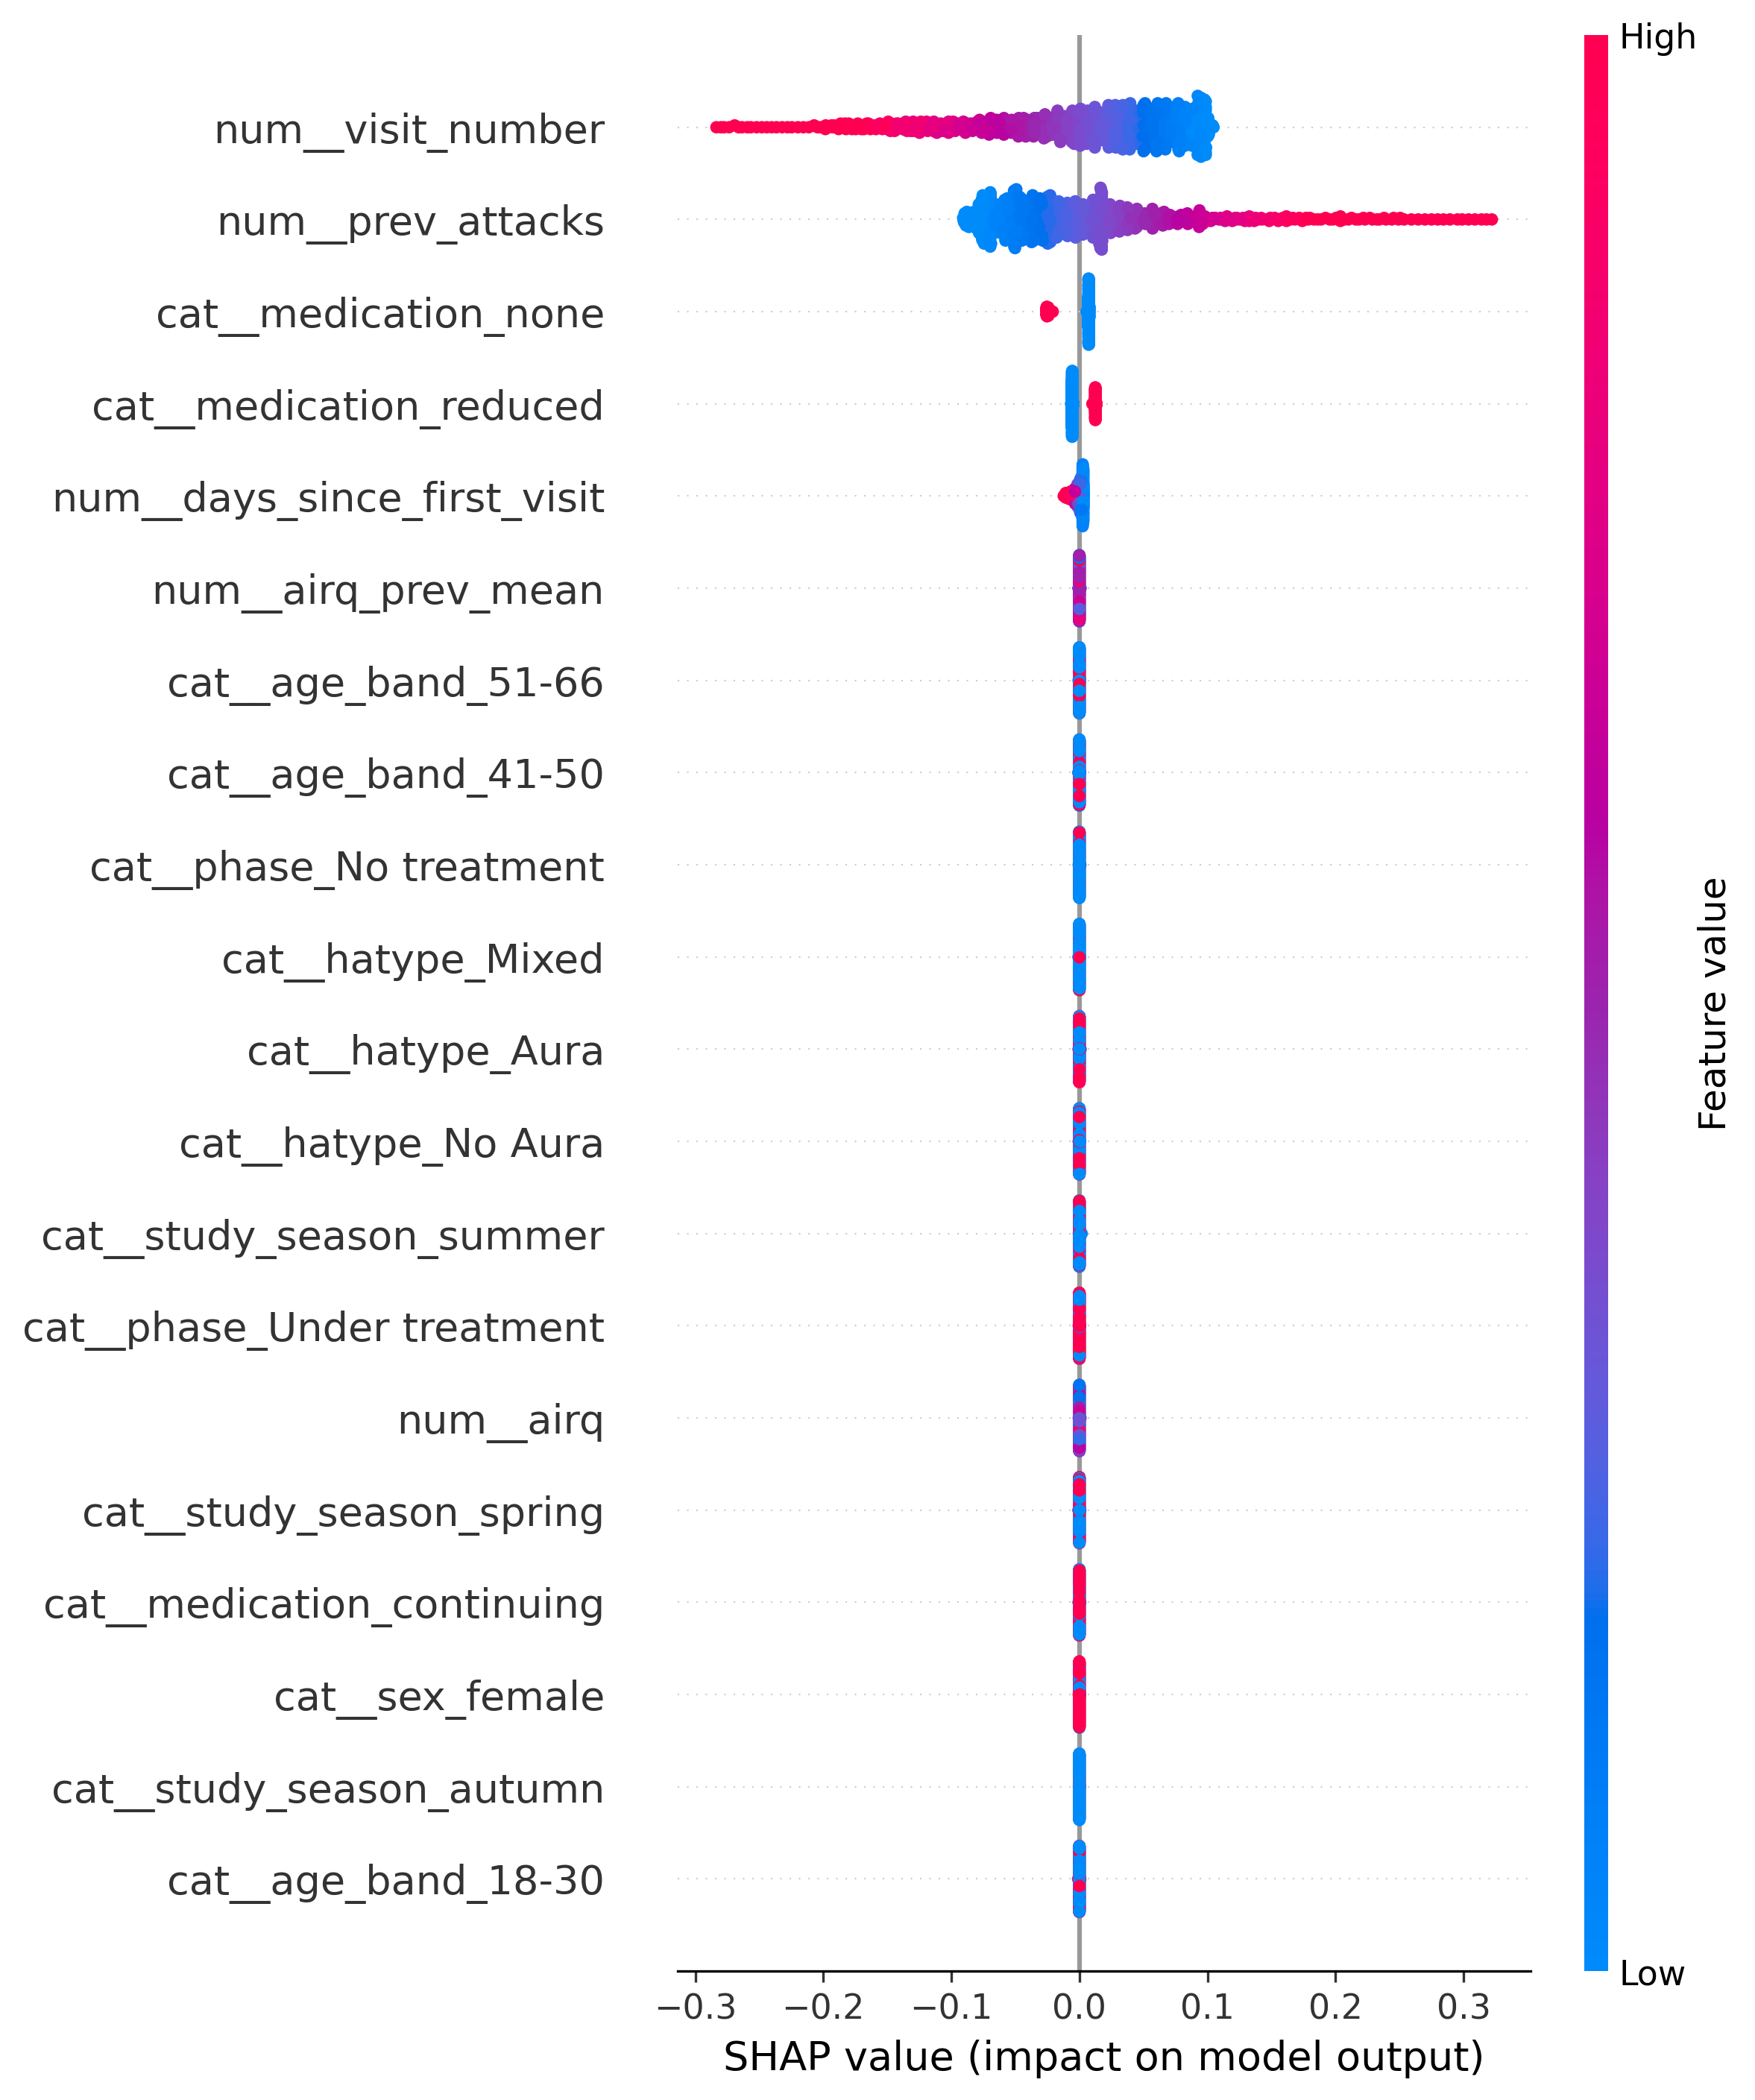

In [18]:
# Beeswarm plot
viz_py$plot_shap_beeswarm(
  shap_values = shap_values,
  X           = X_shap,
  output_path = "../reports/figures/shap_beeswarm.png"
)
IRdisplay::display_png(file = "../reports/figures/shap_beeswarm.png")

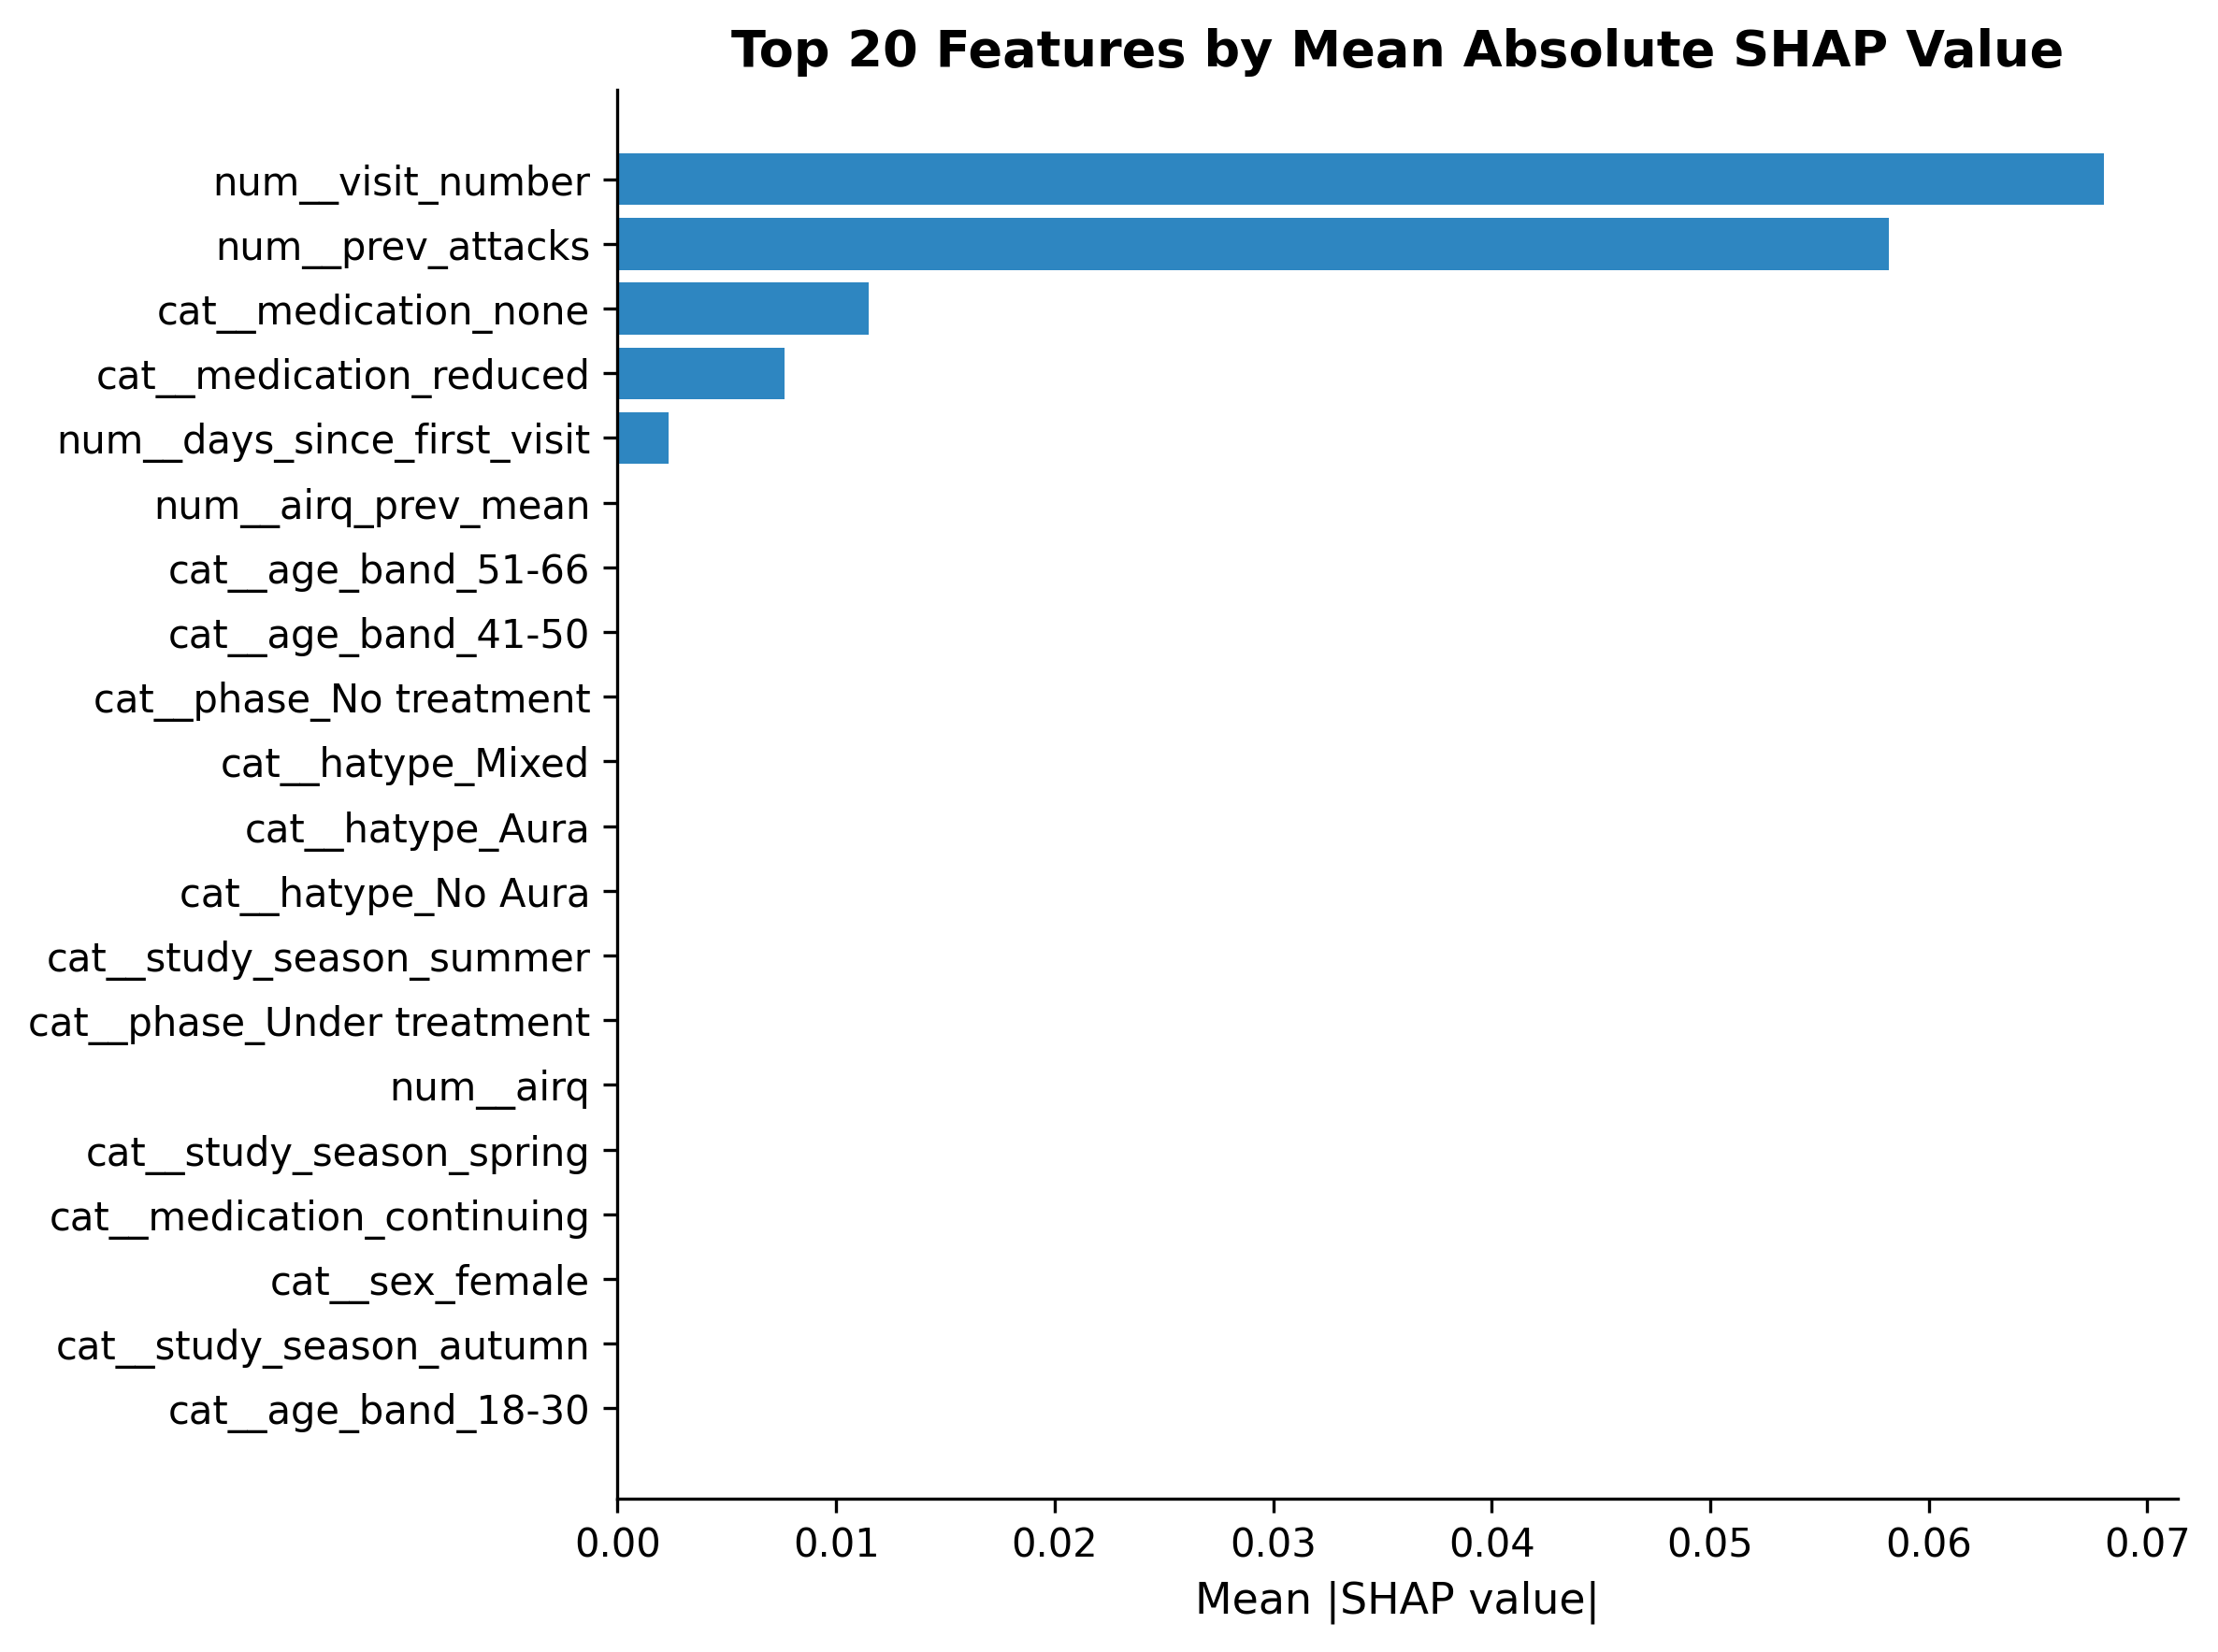

In [19]:
# Bar plot
viz_py$plot_shap_bar(
  shap_values = shap_values,
  X           = X_shap,
  output_path = "../reports/figures/shap_bar.png",
  top_n       = 20L
)
IRdisplay::display_png(file = "../reports/figures/shap_bar.png")

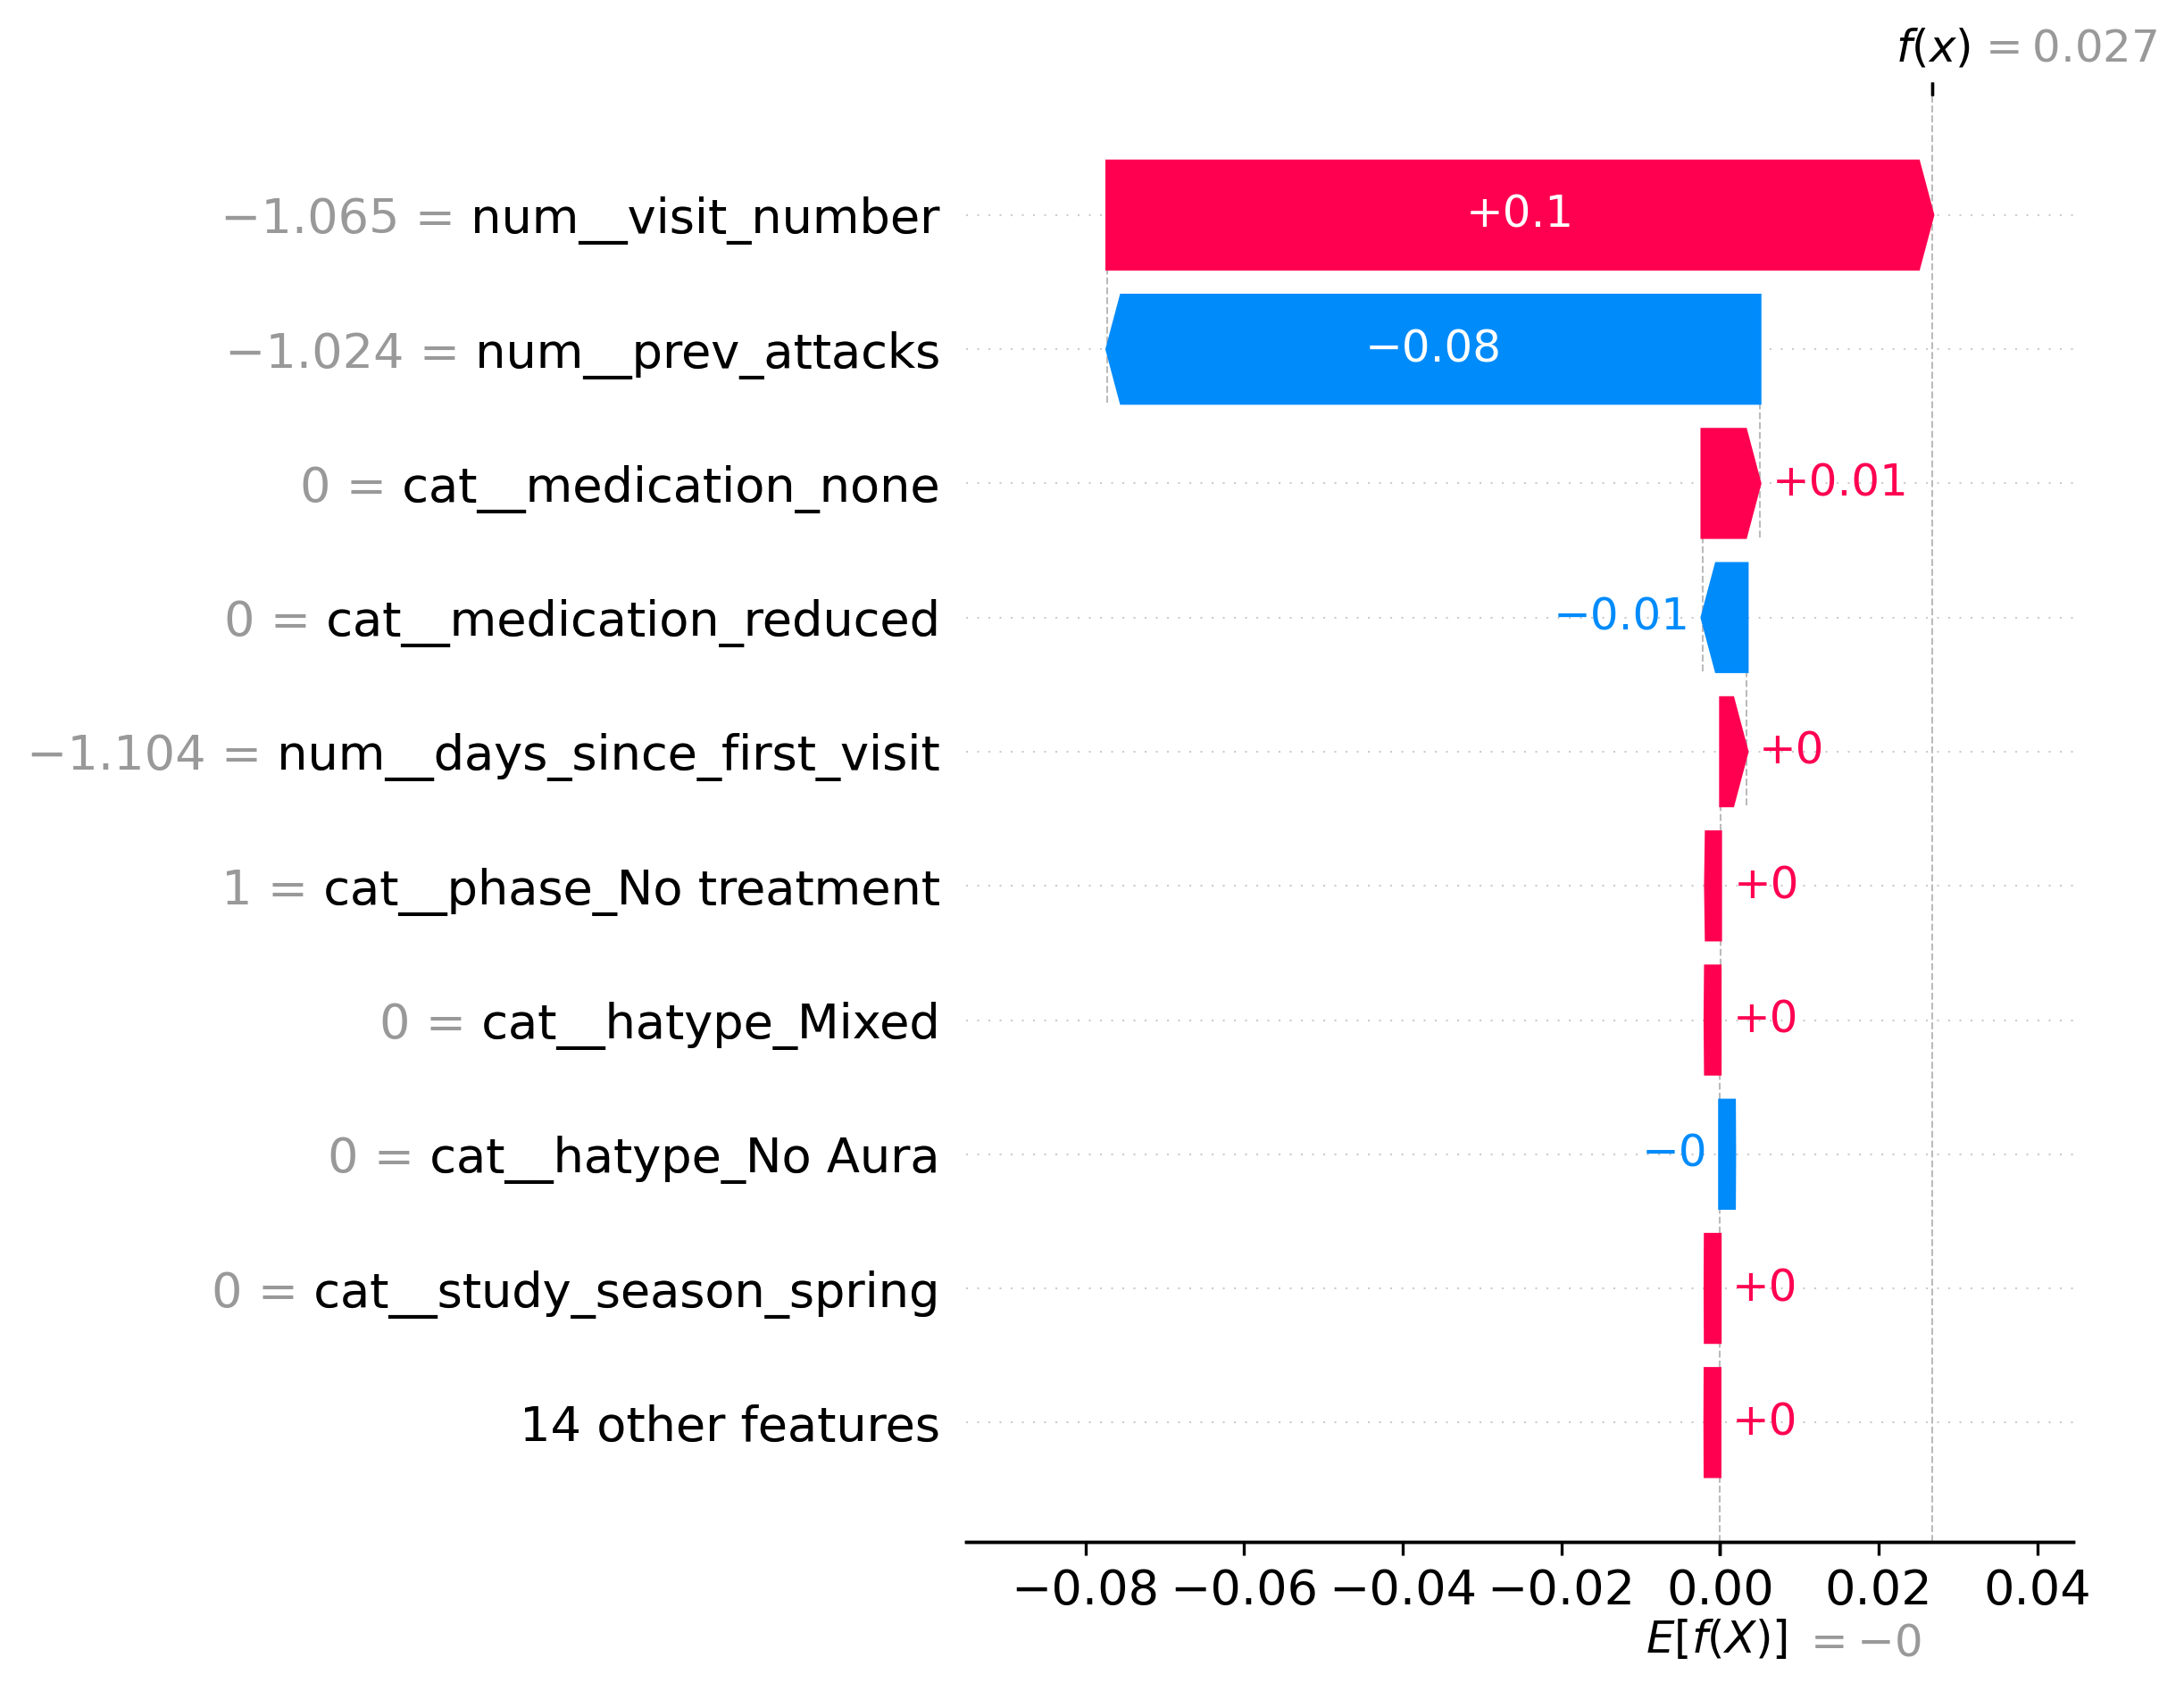

In [20]:
# Waterfall — patient
viz_py$plot_shap_waterfall(
  shap_values = shap_values,
  X           = X_shap,
  patient_idx = 0L,
  output_path = "../reports/figures/shap_waterfall_patient0.png"
)
IRdisplay::display_png(file = "../reports/figures/shap_waterfall_patient0.png")